ИАД

<h1> Частота слов в отзывах </h1>

In [9]:
import psycopg2
import pandas as pd
import os
from dotenv import load_dotenv
load_dotenv()


True

In [11]:
db = psycopg2.connect(
    dbname = os.getenv("PGDATABASE"),
    user = os.getenv("PGUSER"),
    password = "",
    host = "localhost",
    port = 5432
)
reviews_df = pd.read_sql("SELECT review_text from reviews", db)
reviews_df.head()

/var/folders/kl/zp9l_8715tz323g6x87w7pvh0000gn/T/ipykernel_10110/1555961709.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  reviews_df = pd.read_sql("SELECT review_text from reviews", db)


,review_text
0,"Эту книгу можно люто ненавидеть, а можно и гол..."
1,Роман старшей сестры Бронте любят все. Не встр...
2,Многие в окружении читали или смотрели экраниз...
3,"Итак, я долго откладывала чтение ""Грозового Пе..."
4,"Самая лучшая книга — та, которую читаешь с бол..."


Обработка текста

In [12]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kmaxim/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

Токенизация => Морфология => Лемматизация

In [ ]:
from razdel import tokenize

reviews_df["tokens"] = reviews_df["review_text"].apply(
    lambda x: [token.text for token in tokenize(x)]
)




In [38]:
from natasha import (
    Segmenter,
    MorphVocab,
    NewsEmbedding,
    NewsMorphTagger,
    Doc
)
segmenter = Segmenter()
morph_vocab = MorphVocab()
emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)

/Users/kmaxim/Documents/NLP projects/BookRecommendor/.venv/lib/python3.14/site-packages/pymorphy2/analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [41]:
def morpher(text):
    doc = Doc(text)
    doc.segment(segmenter) 
    doc.tag_morph(morph_tagger)
    for token in doc.tokens:
        token.lemmatize(morph_vocab)
    return [token.lemma for token in doc.tokens]
reviews_df["lemmas"] = reviews_df["review_text"].apply(morpher)

In [42]:
reviews_df["lemmas"].head()

0    [этот, книга, можно, люто, ненавидеть, ,, а, м...
1    [роман, старший, сестра, бронт, любить, весь, ...
2    [многие, в, окружение, читать, или, смотреть, ...
3    [итак, ,, я, долго, откладывать, чтение, ", гр...
4    [самый, хороший, книга, —, тот, ,, который, чи...
Name: lemmas, dtype: object

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('russian'))
reviews_df["lemmas_filtered"] = reviews_df["lemmas"].apply(lambda x: [word for word in x if word not in stop_words and word.isalpha()])

<h1>Графики частот без стоп-слов</h1>

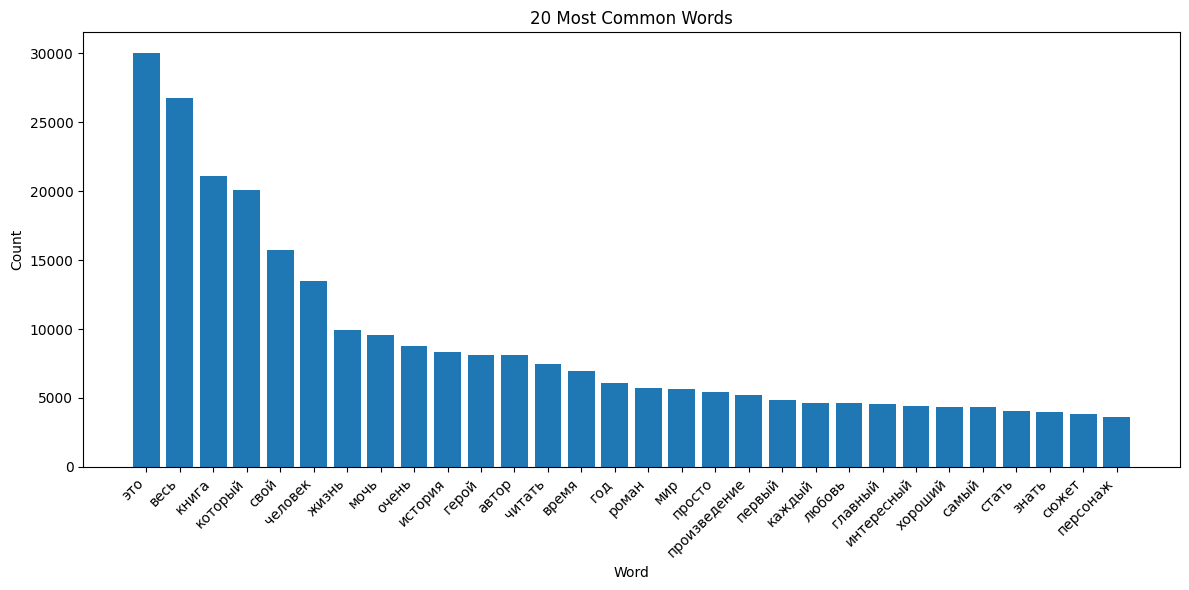

In [54]:
import matplotlib.pyplot as plt
from collections import Counter 
corpus = []
for lemmas in reviews_df["lemmas_filtered"]:  
    for word in lemmas:                        
        corpus.append(word)                     
word_counts = Counter(corpus)
top_30_words = word_counts.most_common(30)
words, counts = zip(*top_30_words)

plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.xticks(rotation=45, ha='right')
plt.title("20 Most Common Words")
plt.xlabel("Word")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [56]:
meaningless = {"который", "книга", "автор", "весь", "это"}
reviews_df["lemmas_filtered_for_fa"] = reviews_df["lemmas_filtered"].apply(lambda x: [word for word in x if word not in meaningless])

In [62]:
from nltk import ngrams

tuples = [trigram for lemmas in reviews_df["lemmas_filtered_for_fa"] for trigram in ngrams(lemmas, 4)]
tuple_count = Counter(tuples)
most_common_tuples = tuple_count.most_common(20)
print(most_common_tuples)

[(('прочитать', 'рамка', 'игра', 'собрать'), 67), (('вечер', 'хутор', 'близ', 'диканька'), 62), (('прочитать', 'рамка', 'игра', 'killwish'), 48), (('прочитать', 'рамка', 'игра', 'классика'), 46), (('прочитать', 'рамка', 'игра', 'книжный'), 40), (('группа', 'читать', 'классика', 'вместе'), 30), (('рецензия', 'написать', 'рамка', 'игра'), 29), (('дикий', 'охота', 'король', 'стах'), 29), (('иван', 'федорович', 'шпонька', 'тетушка'), 28), (('клуб', 'читать', 'классика', 'вместе'), 26), (('вечер', 'накануне', 'иван', 'купала'), 24), (('таинственный', 'история', 'билли', 'миллигана'), 22), (('рамка', 'игра', 'игра', 'классика'), 21), (('доктор', 'джекил', 'мистер', 'хайд'), 20), (('прочитать', 'рамка', 'игра', 'игра'), 19), (('прочитать', 'рамка', 'игра', 'школьный'), 19), (('рамка', 'игра', 'школьный', 'вселенная'), 19), (('иоганн', 'вольфганг', 'фон', 'гете'), 18), (('прочитать', 'рамка', 'игра', 'вокруг'), 18), (('рамка', 'игра', 'вокруг', 'свет'), 18)]
